# Distributed Matrix PageRank on Local Spark (RDD API)

Steps: **1)** start a local Spark node, **2)** build a distributed web graph,
**3)** run PageRank with RDD transformations only (each iteration is one distributed
sparse matrix-vector product), **4)** track convergence.

Update rule: `r_new = d * (M @ r + dangling_mass / N) + (1 - d) / N`

Run the cells top to bottom (needs Java 11+).

In [1]:
# 1. Install and start a local Spark node (skip the pip line if pyspark is already installed)
!pip install -q pyspark matplotlib numpy

import os, sys, random, time
from operator import add
os.environ["PYSPARK_PYTHON"] = sys.executable

from pyspark import SparkConf, SparkContext
sc = SparkContext.getOrCreate(
    SparkConf().setMaster("local[*]").setAppName("MatrixPageRank")
               .set("spark.ui.showConsoleProgress", "false")
               .set("spark.default.parallelism", "8"))   # same partition count everywhere -> co-partitioned joins
sc.setLogLevel("ERROR")
print("Spark", sc.version, "| cores:", sc.defaultParallelism)

Picked up JAVA_TOOL_OPTIONS: -Djavax.net.ssl.trustStore=/etc/ssl/certs/java/cacerts -Djavax.net.ssl.trustStoreType=JKS -Dhttps.proxyHost=127.0.0.1 -Dhttps.proxyPort=46167 -Dhttp.nonProxyHosts=localhost|127.0.0.1|::1|127.*|0.*|::|169.254.*|api.anthropic.com|api-staging.anthropic.com|api-pr-preview.anthropic.com|mcp-proxy.anthropic.com|mcp-proxy-staging.anthropic.com|registry.npmjs.org|jsr.io|npm.jsr.io|pypi.org|files.pythonhosted.org|index.crates.io|proxy.golang.org|host.docker.internal|10.*|172.16.*|172.17.*|172.18.*|172.19.*|172.20.*|172.21.*|172.22.*|172.23.*|172.24.*|172.25.*|172.26.*|172.27.*|172.28.*|172.29.*|172.30.*|172.31.*|192.168.*|100.64.0.0/10|*.svc.cluster.local|*.svc.cluster.local -Djdk.http.auth.tunneling.disabledSchemes= -Djdk.http.auth.proxying.disabledSchemes=


Picked up JAVA_TOOL_OPTIONS: -Djavax.net.ssl.trustStore=/etc/ssl/certs/java/cacerts -Djavax.net.ssl.trustStoreType=JKS -Dhttps.proxyHost=127.0.0.1 -Dhttps.proxyPort=46167 -Dhttp.nonProxyHosts=localhost|127.0.0.1|::1|127.*|0.*|::|169.254.*|api.anthropic.com|api-staging.anthropic.com|api-pr-preview.anthropic.com|mcp-proxy.anthropic.com|mcp-proxy-staging.anthropic.com|registry.npmjs.org|jsr.io|npm.jsr.io|pypi.org|files.pythonhosted.org|index.crates.io|proxy.golang.org|host.docker.internal|10.*|172.16.*|172.17.*|172.18.*|172.19.*|172.20.*|172.21.*|172.22.*|172.23.*|172.24.*|172.25.*|172.26.*|172.27.*|172.28.*|172.29.*|172.30.*|172.31.*|192.168.*|100.64.0.0/10|*.svc.cluster.local|*.svc.cluster.local -Djdk.http.auth.tunneling.disabledSchemes= -Djdk.http.auth.proxying.disabledSchemes=


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/08 10:50:39 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/10/08 10:50:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/08 10:50:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.2.0 | cores: 8


In [2]:
# 2. Generate a synthetic web graph (popular pages attract more links, ~5% dangling pages)
N, AVG_OUT, SEED = 5000, 8, 42
rng = random.Random(SEED)
dangling_set = set(rng.sample(range(N), int(N * 0.05)))
urn = list(range(N))            # preferential attachment urn
edge_list = []
for src in range(N):
    if src in dangling_set:
        continue
    targets = {rng.choice(urn) for _ in range(max(1, int(rng.expovariate(1 / AVG_OUT))))}
    targets.discard(src)
    for dst in targets:
        edge_list.append((src, dst))
        urn.append(dst)
print(f"{N} nodes, {len(edge_list)} edges")

5000 nodes, 35824 edges


In [3]:
# 3. Distributed representation of the graph
PARTS = 8
edges = sc.parallelize(edge_list, PARTS)

# links = sparse row-wise transition matrix: (page, [pages it links to]); dangling pages -> []
links = (sc.parallelize(range(N), PARTS).map(lambda n: (n, []))
           .union(edges.groupByKey().mapValues(list))
           .reduceByKey(lambda a, b: a + b)
           .partitionBy(PARTS)
           .cache())

# ranks = the vector r, initialised uniformly
ranks = links.mapValues(lambda _: 1.0 / N)
print("pages:", links.count(), "| dangling:", links.filter(lambda kv: not kv[1]).count())

pages: 5000 | dangling: 250


In [4]:
# 4. PageRank: iterative distributed matrix-vector multiplication
D, TOL, MAX_ITER = 0.85, 1e-8, 100
zeros = links.mapValues(lambda _: 0.0)       # makes sure pages with no in-links still get a rank
history = []

for it in range(1, MAX_ITER + 1):
    t0 = time.time()
    joined = links.join(ranks).cache()                       # (page, (outlinks, rank))

    dangling_mass = (joined.filter(lambda kv: not kv[1][0])
                           .map(lambda kv: kv[1][1]).sum())  # rank stuck on dangling pages

    # y = M r : every page sends rank/outdegree to each page it links to, then sum per target
    contribs = joined.flatMap(lambda kv: [(d, kv[1][1] / len(kv[1][0])) for d in kv[1][0]])
    mat_vec = contribs.union(zeros).reduceByKey(add)

    base = (1 - D) / N + D * dangling_mass / N
    new_ranks = mat_vec.mapValues(lambda s: base + D * s)
    new_ranks.localCheckpoint()         # keep the result and cut the lineage so iterations stay fast

    delta = new_ranks.join(ranks).map(lambda kv: abs(kv[1][0] - kv[1][1])).sum()  # L1 change
    new_ranks.count()                   # materialise the checkpoint
    history.append(delta)
    print(f"iter {it:3d}   L1 delta = {delta:.3e}   ({time.time() - t0:.1f}s)")

    ranks.unpersist(); joined.unpersist()
    ranks = new_ranks
    if delta < TOL:
        print(f"Converged after {it} iterations")
        break

iter   1   L1 delta = 6.918e-01   (2.5s)


iter   2   L1 delta = 2.545e-01   (2.6s)


iter   3   L1 delta = 1.107e-01   (2.4s)


iter   4   L1 delta = 4.986e-02   (2.3s)


iter   5   L1 delta = 2.282e-02   (2.2s)


...

iter  21   L1 delta = 1.082e-07   (2.0s)


iter  22   L1 delta = 5.127e-08   (2.2s)


iter  23   L1 delta = 2.466e-08   (2.2s)


iter  24   L1 delta = 1.147e-08   (2.1s)


iter  25   L1 delta = 5.280e-09   (2.2s)
Converged after 25 iterations


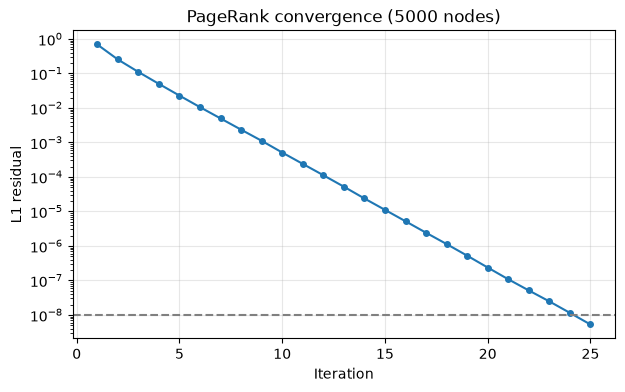

Sum of ranks: 1.0 (should be 1.0)

 #   page    pagerank  in-links


 1   4831    0.002293        39
 2   3725    0.002037        55
 3   3149    0.001977        12
 4    479    0.001717        23
 5    879    0.001629        32
 6   3849    0.001589        41
 7   3809    0.001555        79
 8   3433    0.001552        37
 9    699    0.001500        26
10   4539    0.001479        13


In [5]:
# 5. Results: convergence curve and top pages
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.semilogy(range(1, len(history) + 1), history, "o-", ms=4)
plt.axhline(TOL, ls="--", color="gray")
plt.xlabel("Iteration"); plt.ylabel("L1 residual"); plt.grid(alpha=.3)
plt.title(f"PageRank convergence ({N} nodes)")
plt.show()

in_deg = links.flatMap(lambda kv: [(d, 1) for d in kv[1]]).reduceByKey(add).collectAsMap()
print("Sum of ranks:", round(ranks.map(lambda kv: kv[1]).sum(), 10), "(should be 1.0)\n")
print(f"{'#':>2} {'page':>6} {'pagerank':>11} {'in-links':>9}")
for i, (page, r) in enumerate(ranks.takeOrdered(10, key=lambda kv: -kv[1]), 1):
    print(f"{i:>2} {page:>6} {r:>11.6f} {in_deg.get(page, 0):>9}")

In [6]:
# 6. Sanity check against a plain NumPy power iteration (should match to ~1e-10 or better)
import numpy as np
src = np.array([e[0] for e in edge_list]); dst = np.array([e[1] for e in edge_list])
outdeg = np.bincount(src, minlength=N)
r = np.full(N, 1.0 / N)
for _ in range(300):
    contrib = np.bincount(dst, weights=(r / np.maximum(outdeg, 1))[src], minlength=N)
    r = (1 - D) / N + D * (contrib + r[outdeg == 0].sum() / N)
spark_r = np.array([v for _, v in sorted(ranks.collect())])
print("max |Spark - NumPy| =", np.abs(spark_r - r).max())

max |Spark - NumPy| = 3.028279114015292e-11


In [7]:
sc.stop()